In [2]:
from hossam import load_data
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from scipy.spatial import ConvexHull
from sklearn.preprocessing import MinMaxScaler, StandardScaler

my_dpi = 200


In [3]:
from sklearnex  import patch_sklearn
patch_sklearn()

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [4]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [ ]:
origin = load_data("game_usage")
origin.head()

게임 이용시간(time spent)과 레벨(game level)에 대한 가상 데이터


,time spent,game level
0,39,944
1,55,705
2,29,757
3,59,999
4,7,109


In [13]:
estimator = KMeans(n_clusters=4)

estimator.fit(origin)

cluster_pred = estimator.predict(origin)
cluster_pred

array([2, 1, 1, 2, 0, 1, 3, 3, 0, 3, 2, 1, 0, 3, 2, 0, 1, 0, 2, 1, 1, 2,
       0, 1, 0, 2, 1, 0, 3, 1, 1, 1, 3, 0, 1, 1, 3, 0, 0, 2, 3, 1, 2, 1,
       2, 1, 1, 3, 1, 0, 3, 0, 0, 0, 3, 2, 0, 1, 2, 3, 0, 1, 3, 3, 3, 1,
       3, 0, 3, 1, 2, 3, 0, 0, 2, 0, 2, 2, 0, 3, 0, 1, 3, 2, 0, 1, 1, 3,
       0, 0, 1, 1, 3, 1, 2, 2, 3, 2, 0, 3], dtype=int32)

📌 [1] 머신러닝 학습시키기 (K-Means 군집화)
🔍 문제 정의

사용자의 행동 데이터를 기반으로 유사한 유형의 사용자 그룹을 자동으로 분류하는 것이 목적입니다.
여기서는 KMeans 알고리즘을 사용해 4개의 그룹으로 군집화합니다.

🎯 분류하고 싶은 사용자 유형 (해석 관점)

오래해서 잘하는 사용자

오래했지만 못하는 사용자

잠깐 했는데 잘하는 사용자

잠깐 했고 못하는 사용자

In [14]:
df = origin.copy()
df["그룹번호"] = cluster_pred
df

,time spent,game level,그룹번호
0,39,944,2
1,55,705,1
2,29,757,1
3,59,999,2
4,7,109,0
...,...,...,...
95,47,939,2
96,50,485,3
97,13,916,2
98,79,235,0


## 📝[3]결과 시각화

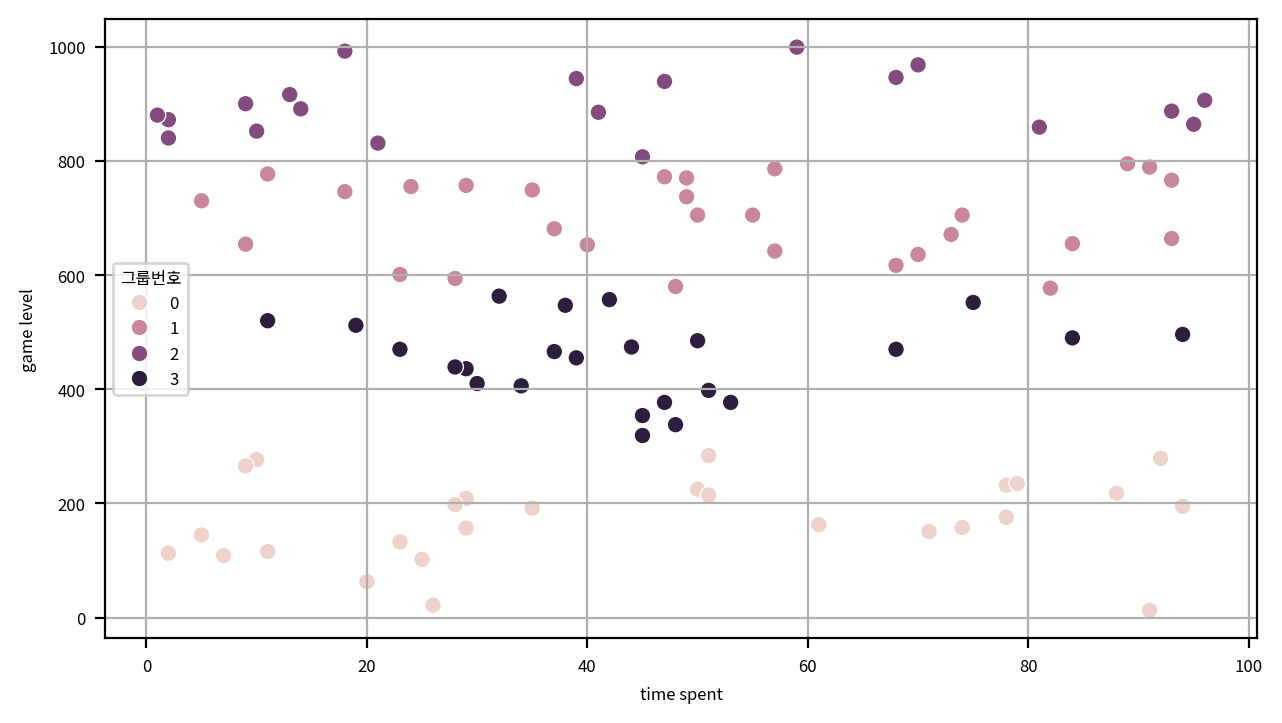

In [15]:
width_px = 1280
height_px = 720
rows = 1
cols=1
figsize = (width_px /my_dpi, height_px/my_dpi)
fig, ax = plt.subplots(rows,cols,figsize=figsize, dpi=my_dpi)

# 그래프 그리기->seaborn 사용
sb.scatterplot(data=df, x="time spent",y = "game level" ,hue="그룹번호")
            

ax.grid()
plt.tight_layout()
plt.show()
plt.close()


## 📝[3]결과 시각화(고급)

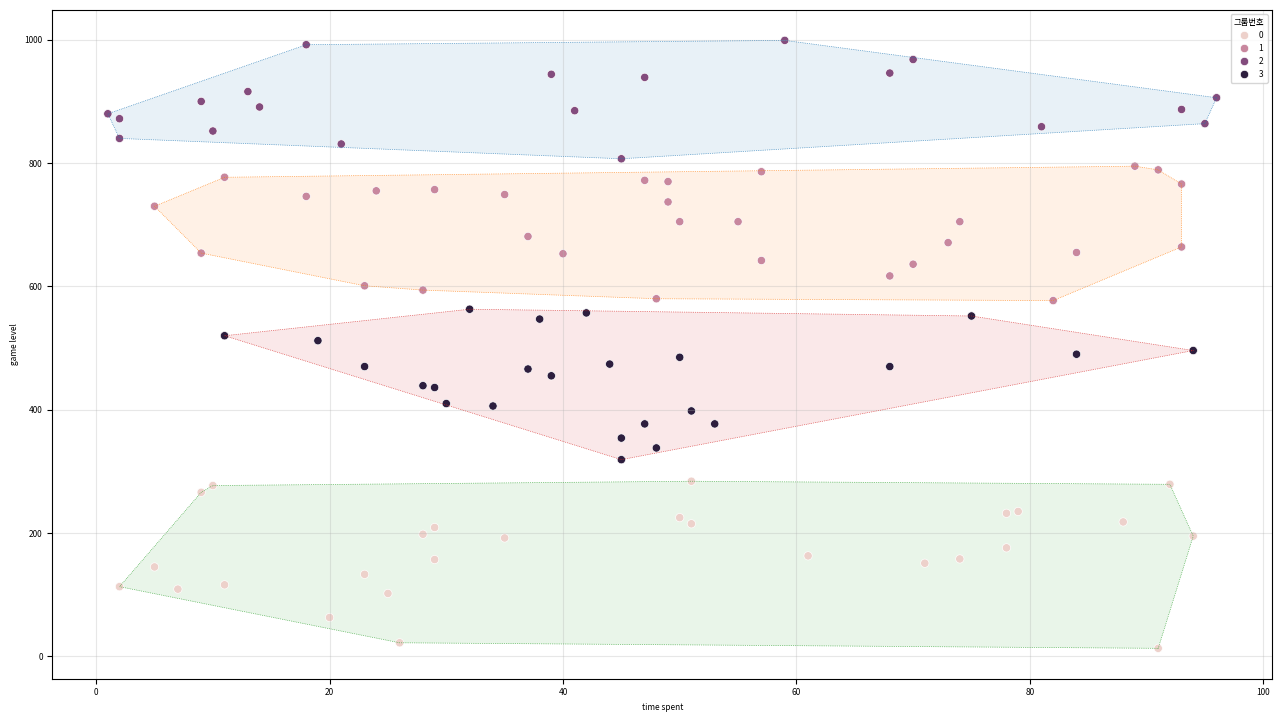

In [16]:
# 그래프 해상도 설정
width_px = 1280   # 그래프 가로 크기
height_px = 720   # 그래프 세로 크기
my_dpi = 100

rows = 1          # 그래프 행 수
cols = 1          # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(
    rows,
    cols,
    figsize=figsize,
    dpi=my_dpi
)

# -------------------------------
# 군집별 영역 시각화
# -------------------------------

for c in df["그룹번호"].unique():

    # 현재 군집 데이터만 추출
    df_c = df.loc[df["그룹번호"] == c, ["time spent", "game level"]]

    try:
        # 외곽선(Convex Hull) 계산
        hull = ConvexHull(df_c)

        # 마지막 점과 첫 점을 연결하여 폐곡선 생성
        points = np.append(hull.vertices, hull.vertices[0])

        # 외곽선 그리기
        ax.plot(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            linewidth=0.5,
            linestyle=":"
        )

        # 영역 채우기
        ax.fill(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            alpha=0.1
        )

    except:
        # 데이터 포인트가 부족한 군집은 무시
        pass

# 산점도 시각화
sb.scatterplot(
    data=df,
    x="time spent",
    y="game level",
    hue="그룹번호"
)

# 그래프 옵션
ax.grid(True, alpha=0.3)
plt.tight_layout()

# 출력 및 종료
plt.show()
plt.close()


## 📝[1]표준화 되지 않은 원본 데이트러를 x와 y축에 대하여 같은 범위로 설정하고 시각화

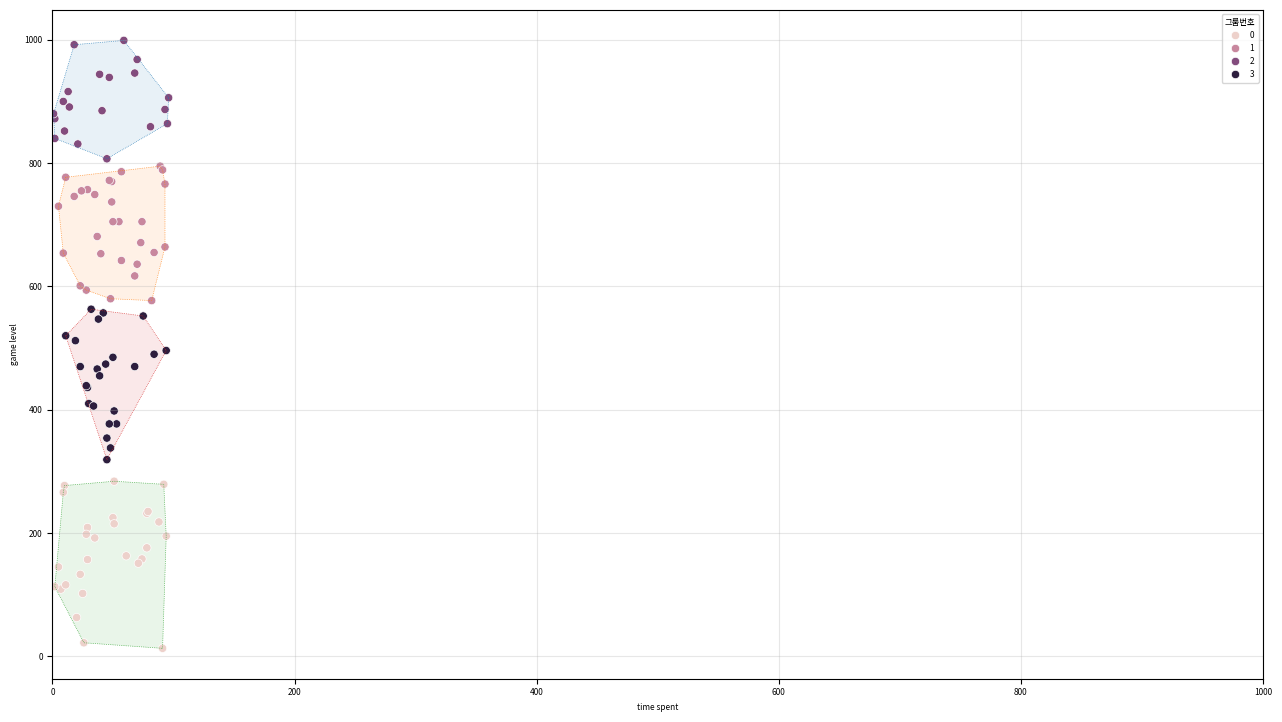

In [17]:
# 1) 그래프 초기화
width_px = 1280   # 그래프 가로 크기
height_px = 720   # 그래프 세로 크기

rows = 1          # 그래프 행 수
cols = 1          # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(
    rows,
    cols,
    figsize=figsize,
    dpi=my_dpi
)

# -------------------------------
# 그리기 코드
# -------------------------------
# 군집별 데이터 반복
for c in df["그룹번호"].unique():

    # 군집별 데이터프레임 나눔
    df_c = df.loc[
        df["그룹번호"] == c,
        ["time spent", "game level"]
    ]

    try:
        # 외각선 좌표 계산
        hull = ConvexHull(df_c)

        # 마지막 좌표 이후 첫 번째 좌표를 연결
        points = np.append(
            hull.vertices,
            hull.vertices[0]
        )

        # 외곽선 그리기
        ax.plot(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            linewidth=0.5,
            linestyle=":"
        )

        # 영역 채우기
        ax.fill(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            alpha=0.1
        )

    except:
        pass


# 전체 산점도
sb.scatterplot(
    data=df,
    x="time spent",
    y="game level",
    hue="그룹번호"
)

# 그래프 옵션
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1000)

plt.tight_layout()
plt.show()
plt.close()



## 📝[2]데이터 스케일링에 대한 군집화
- ✏️(1)Standard Scaler

In [19]:
scaler = StandardScaler()
sdf = DataFrame(scaler.fit_transform(origin), columns = origin.columns)
sdf

,time spent,game level
0,-0.250733,1.474805
1,0.326494,0.606546
2,-0.611500,0.795456
3,0.470801,1.674613
4,-1.405187,-1.558652
...,...,...
95,0.037881,1.456640
96,0.146111,-0.192688
97,-1.188727,1.373084
98,1.192335,-1.100909


In [22]:
# 모델 객체 생성
estimator == KMeans(n_clusters = 4)

# 모델학습
estimator.fit(sdf)

# 예측
cluster= estimator.predict(sdf)
sdf["그룹번호"] = cluster
sdf

,time spent,game level,그룹번호
0,-0.250733,1.474805,0
1,0.326494,0.606546,2
2,-0.611500,0.795456,0
3,0.470801,1.674613,2
4,-1.405187,-1.558652,1
...,...,...,...
95,0.037881,1.456640,2
96,0.146111,-0.192688,1
97,-1.188727,1.373084,0
98,1.192335,-1.100909,3


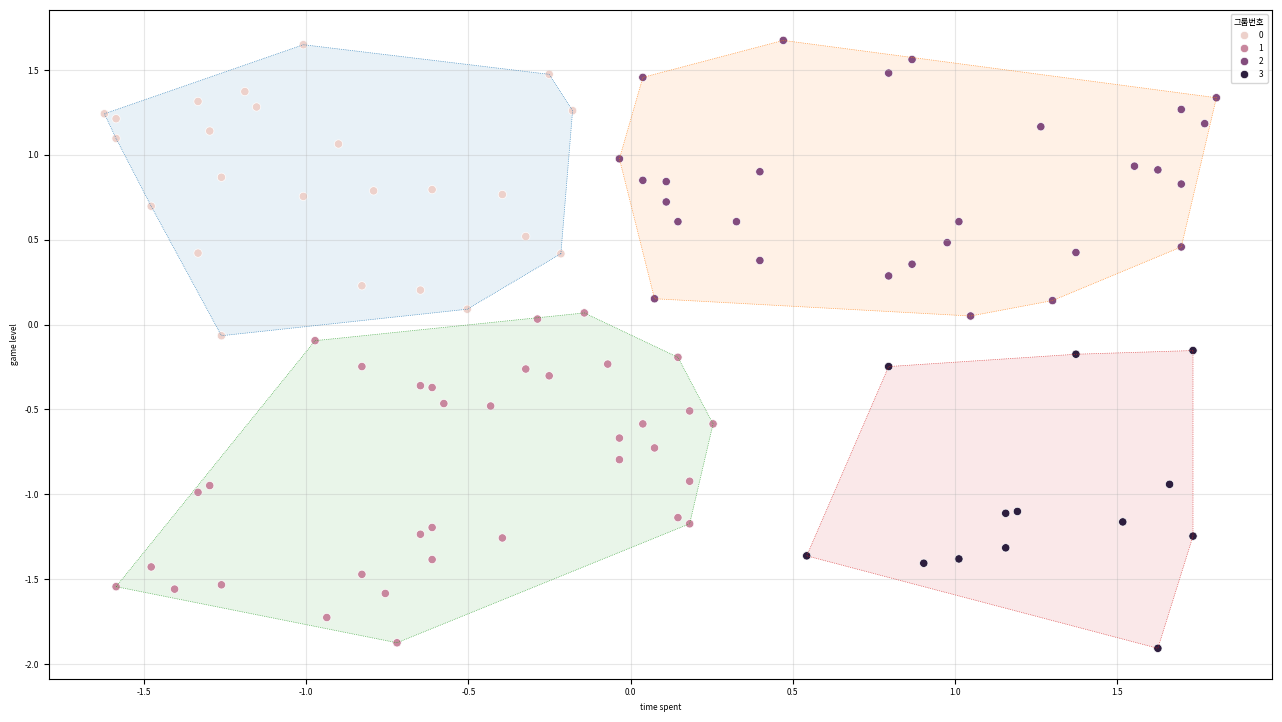

In [24]:
# 1) 그래프 초기화
width_px = 1280   # 그래프 가로 크기
height_px = 720   # 그래프 세로 크기

rows = 1          # 그래프 행 수
cols = 1          # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(
    rows,
    cols,
    figsize=figsize,
    dpi=my_dpi
)

# -------------------------------
# 그리기 코드
# -------------------------------
# 군집 번호별 반복
for c in sdf["그룹번호"].unique():

    # 군집별 데이터프레임 나눔
    df_c = sdf.loc[
        sdf["그룹번호"] == c,
        ["time spent", "game level"]
    ]

    try:
        # 외곽선 좌표 계산
        hull = ConvexHull(df_c)

        # 마지막 좌표 이후 첫 번째 좌표 연결
        points = np.append(
            hull.vertices,
            hull.vertices[0]
        )

        # 외곽선 그리기
        ax.plot(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            linewidth=0.5,
            linestyle=":"
        )

        # 영역 채우기
        ax.fill(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            alpha=0.1
        )

    except Exception:
        pass


# 전체 산점도
sb.scatterplot(
    data=sdf,
    x="time spent",
    y="game level",
    hue="그룹번호"
)

# 그래프 옵션
ax.grid(True, alpha=0.3)

plt.tight_layout()   # 여백 제거
plt.show()           # 그래프 화면 출력
plt.close()          # 그래프 작업 종료


## 📝(2)MinMax Scaler

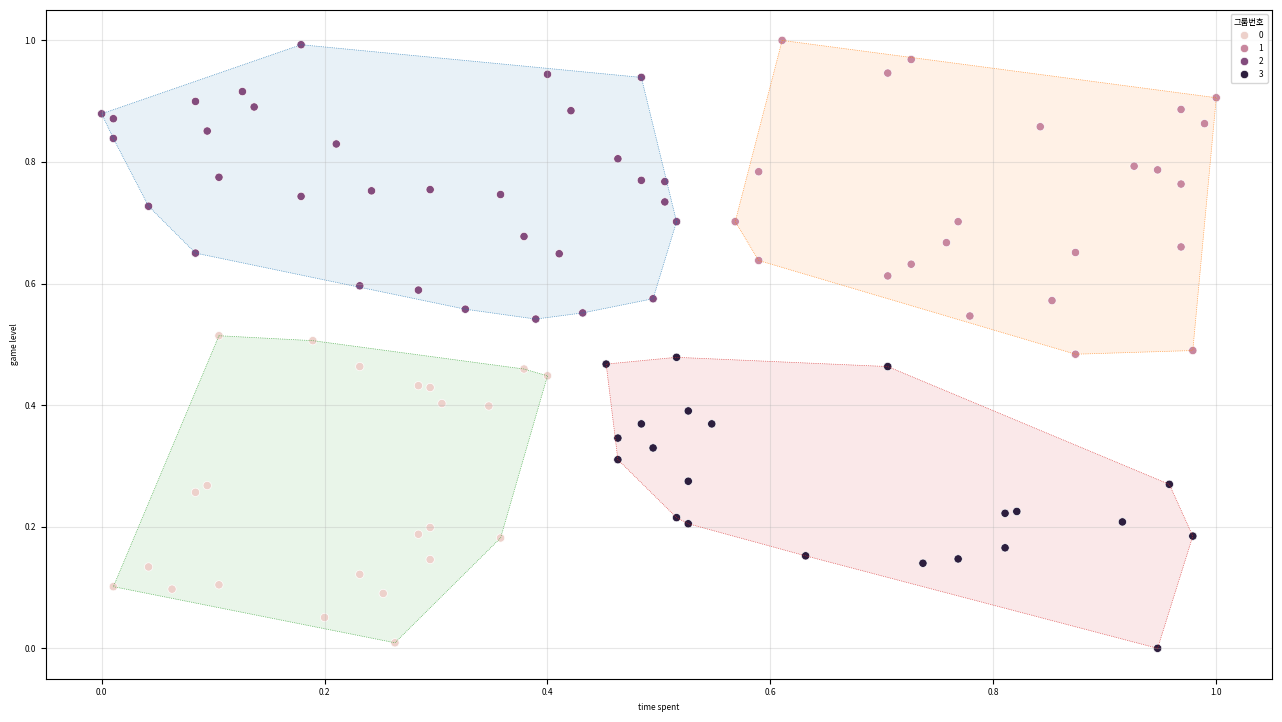

In [39]:

# -------------------------------
# 스케일링
# -------------------------------
scaler = MinMaxScaler()
mdf = DataFrame(
    scaler.fit_transform(origin),
    columns=origin.columns
)

# -------------------------------
# 모델 객체 생성
# -------------------------------
estimator = KMeans(n_clusters=4)

# -------------------------------
# 모델 학습
# -------------------------------
estimator.fit(mdf)

# -------------------------------
# 예측 및 결과 저장
# -------------------------------
cluster = estimator.predict(mdf)
mdf["그룹번호"] = cluster


# -------------------------------
# 1) 그래프 초기화
# -------------------------------
width_px = 1280   # 그래프 가로 크기
height_px = 720   # 그래프 세로 크기

rows = 1          # 그래프 행 수
cols = 1          # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(
    rows,
    cols,
    figsize=figsize,
    dpi=my_dpi
)

# -------------------------------
# 고급 시각화 코드
# -------------------------------
# 군집 번호별 반복
for c in mdf["그룹번호"].unique():

    # 군집별 데이터프레임 분리
    df_c = mdf.loc[
        mdf["그룹번호"] == c,
        ["time spent", "game level"]
    ]

    try:
        # 외곽선 좌표 계산
        hull = ConvexHull(df_c)

        # 마지막 좌표 이후 첫 번째 좌표 연결
        points = np.append(
            hull.vertices,
            hull.vertices[0]
        )

        # 외곽선 그리기
        ax.plot(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            linewidth=0.5,
            linestyle=":"
        )

        # 영역 채우기
        ax.fill(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            alpha=0.1
        )

    except Exception:
        pass


# -------------------------------
# 전체 산점도
# -------------------------------
sb.scatterplot(
    data=mdf,
    x="time spent",
    y="game level",
    hue="그룹번호"
)

# -------------------------------
# 그래프 옵션 및 출력
# -------------------------------
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()     # 그래프 화면 출력
plt.close()    # 그래프 작업 종료
